# 27. Hierarchical Clustering Project

## Proje Tanıtımı

Bu projede Wine veri seti üzerinde Hierarchical Clustering yani Hiyerarşik Kümeleme algoritmasını uygulayacağız.

Hiyerarşik Kümeleme, gözetimsiz öğrenme yöntemlerinden biridir.  
Bu yöntemde veriler benzerliklerine göre adım adım gruplanır ve bu gruplama süreci dendrogram adı verilen ağaç benzeri bir grafikle gösterilir.

Bu projenin amacı, şarap örneklerini kimyasal özelliklerine göre kümelere ayırmaktır.  
Model eğitilirken gerçek sınıf etiketleri kullanılmayacaktır.

## Proje Yol Haritası

1. Gerekli kütüphanelerin içe aktarılması  
2. Wine veri setinin yüklenmesi  
3. Özellik verilerinin hazırlanması  
4. Verilerin standartlaştırılması  
5. Dendrogram grafiğinin oluşturulması  
6. Hiyerarşik kümeleme modelinin eğitilmesi  
7. Küme etiketlerinin veri setine eklenmesi  
8. Kümelerin görselleştirilmesi  
9. Kümelerin gerçek sınıflarla karşılaştırılması  
10. Kümeleme performansının değerlendirilmesi  
11. Model ve proje dosyalarının kaydedilmesi  
12. Streamlit uygulamasının oluşturulması  
13. Proje sonucunun yazılması

In [1]:
# Gerekli kütüphaneleri içe aktarıyoruz
import pandas as pd, matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler


## Veri Setinin Yüklenmesi

Bu adımda Scikit-learn kütüphanesi içinden Wine veri setini yüklüyoruz.

Wine veri seti, farklı şarap örneklerine ait kimyasal ölçümlerden oluşur.  
Veri setinde gerçek sınıf bilgisi de vardır ancak bu bilgi model eğitimi sırasında kullanılmayacaktır.

Çünkü bu proje bir gözetimsiz öğrenme projesidir.

In [2]:
# Wine veri setini yüklüyor ve tabloya çeviriyoruz
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## Veri Setinin İncelenmesi

Bu adımda veri setinin genel yapısını kontrol ediyoruz.

Önce sütunları, veri tiplerini ve eksik değer olup olmadığını inceliyoruz.  
Bu kontrol, modelleme aşamasına geçmeden önce veri setinin temiz ve kullanılabilir olup olmadığını anlamamızı sağlar.

In [3]:
# Veri setinin genel yapısını kontrol ediyoruz
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

In [4]:
# Sayısal değişkenlerin temel istatistiklerini inceliyoruz
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


## Özellik Verilerinin Hazırlanması

Bu projede model eğitimi sırasında gerçek sınıf etiketlerini kullanmayacağız.

Bu nedenle sadece şarap örneklerine ait kimyasal ölçümleri kullanarak kümeleme yapacağız.  
Bu, gözetimsiz öğrenmenin temel mantığına uygundur.

In [5]:
# Kümeleme için özellik verilerini hazırlıyoruz
X = df.copy()
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## Verilerin Standartlaştırılması

Bu adımda veri setindeki sayısal değişkenleri standartlaştırıyoruz.

Hiyerarşik kümeleme, veri noktaları arasındaki mesafelere göre çalışır.  
Bu nedenle büyük ölçekli değişkenlerin modeli gereğinden fazla etkilemesini önlemek için StandardScaler kullanıyoruz.

In [6]:
# Verileri standartlaştırıyoruz
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Dendrogram Grafiği

Bu adımda dendrogram grafiği oluşturuyoruz.

Dendrogram, veri noktalarının nasıl gruplandığını ağaç yapısı şeklinde gösterir.  
Bu grafik sayesinde uygun küme sayısı hakkında fikir edinebiliriz.

In [7]:
# Dendrogram için gerekli kütüphaneleri içe aktarıyoruz
from scipy.cluster.hierarchy import dendrogram, linkage

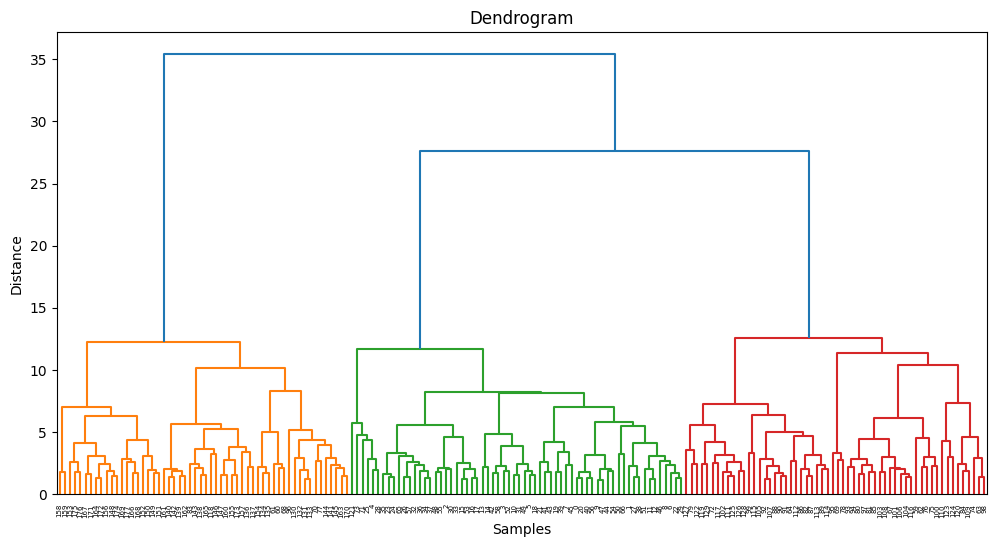

In [8]:
# Dendrogram grafiğini oluşturuyoruz
linked = linkage(X_scaled, method="ward")
plt.figure(figsize=(12, 6))
dendrogram(linked)
plt.title("Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

## Dendrogram Sonucunun Yorumlanması

Dendrogram grafiği, veri noktalarının benzerliklerine göre nasıl birleştiğini gösterir.

Grafikte büyük dikey mesafe boşluklarına bakarak uygun küme sayısı tahmin edilebilir.  
Wine veri setinde doğal olarak 3 farklı sınıf bulunduğu için bu projede küme sayısını **3** olarak belirliyoruz.

Ancak model eğitimi sırasında gerçek sınıf etiketleri kullanılmayacaktır.

In [9]:
# Hiyerarşik kümeleme modelini 3 küme ile eğitiyoruz
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters=3, linkage="ward")

In [10]:
# Modelin ürettiği küme etiketlerini alıyoruz
clusters = hc.fit_predict(X_scaled)
clusters[:10]

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

## Model Eğitimi

Bu adımda Hiyerarşik Kümeleme modeli 3 küme oluşturacak şekilde eğitildi.

Model, şarap örneklerini kimyasal özelliklerine göre gruplandırdı.  
Bu işlem sırasında gerçek sınıf bilgisi kullanılmadı.

In [11]:
# Bulunan küme etiketlerini veri setine ekliyoruz
df["Cluster"] = clusters
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Cluster
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,2
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,2
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,2
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,2
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,2


## Kümelerin Görselleştirilmesi

Wine veri setinde çok sayıda sayısal özellik bulunduğu için kümeleri doğrudan iki boyutlu grafikte göstermek zordur.

Bu nedenle PCA yöntemi ile veri 2 boyuta indirilecektir.  
Bu işlem sadece görselleştirme amacıyla yapılır.

Grafikte her renk, Hiyerarşik Kümeleme algoritmasının oluşturduğu farklı bir kümeyi temsil eder.

In [12]:
# Veriyi görselleştirmek için PCA ile 2 boyuta indiriyoruz
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


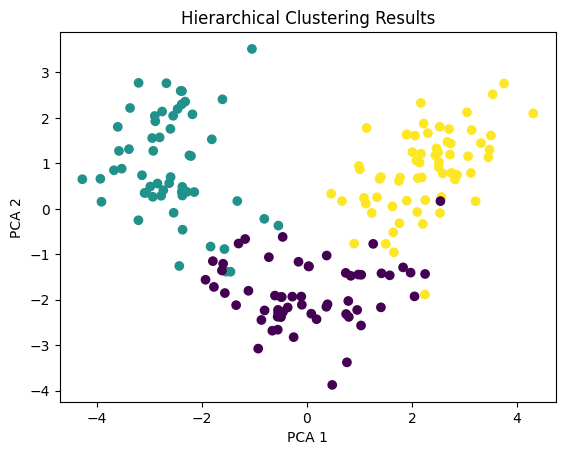

In [13]:
# Hiyerarşik kümeleme sonuçlarını görselleştiriyoruz
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Hierarchical Clustering Results")
plt.show()

## Gerçek Sınıflarla Karşılaştırma

Bu adımda modelin oluşturduğu kümeleri Wine veri setindeki gerçek sınıflarla karşılaştırıyoruz.

Burada dikkat edilmesi gereken nokta şudur:  
Küme numaraları doğrudan gerçek sınıf isimleri anlamına gelmez.

Örneğin Cluster 0, doğrudan Class 0 demek değildir.  
Hiyerarşik kümeleme sadece benzer verileri aynı gruba toplamaya çalışır.

In [14]:
# Gerçek sınıf etiketlerini karşılaştırma için veri setine ekliyoruz
df["Actual_Class"] = wine.target
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Cluster,Actual_Class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,2,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,2,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,2,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,2,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,2,0


In [15]:
# Gerçek sınıflar ile bulunan kümeleri karşılaştırıyoruz
pd.crosstab(df["Actual_Class"], df["Cluster"])

Cluster,0,1,2
Actual_Class,,,
0,0,0,59
1,58,8,5
2,0,48,0


## Kümeleme Performansının Ölçülmesi

Bu adımda kümeleme sonucunu Adjusted Rand Score ile değerlendiriyoruz.

Adjusted Rand Score, modelin oluşturduğu kümeler ile gerçek sınıfların ne kadar benzer olduğunu gösterir.  
Skor 1'e yaklaştıkça kümeleme sonucu gerçek sınıflara daha çok benzer.

In [16]:
# Kümeleme başarısını Adjusted Rand Score ile ölçüyoruz
from sklearn.metrics import adjusted_rand_score
adjusted_rand_score(df["Actual_Class"], df["Cluster"])

0.7899332213582837

## Model Dosyalarının Kaydedilmesi

Hiyerarşik Kümeleme modeli yeni veriler için doğrudan predict fonksiyonu kullanmaz.

Bu nedenle uygulamada kullanmak için scaler, PCA nesnesi, hiyerarşik kümeleme modeli ve küme merkezleri kaydedilecektir.  
Yeni gelen veri, standartlaştırıldıktan sonra en yakın küme merkezine göre bir kümeye atanacaktır.

In [17]:
# Küme merkezlerini hesaplıyoruz
import numpy as np
centroids = np.array([X_scaled[df["Cluster"] == i].mean(axis=0) for i in sorted(df["Cluster"].unique())])

In [18]:
# Model ve yardımcı nesneleri kaydediyoruz
import joblib
joblib.dump(hc, "hierarchical_wine_model.pkl")
joblib.dump(scaler, "hierarchical_wine_scaler.pkl")
joblib.dump(centroids, "hierarchical_wine_centroids.pkl")

['hierarchical_wine_centroids.pkl']

In [19]:
# Kaydedilen dosyaları kontrol ediyoruz
import os
[f for f in os.listdir() if f.endswith(".pkl")]

['hierarchical_wine_model.pkl',
 'hierarchical_wine_scaler.pkl',
 'hierarchical_wine_centroids.pkl']

## Streamlit Uygulamasının Oluşturulması

Bu adımda projeyi web uygulaması haline getirmek için Streamlit dosyası oluşturuyoruz.

Kullanıcı uygulamada şarap örneğine ait kimyasal değerleri girecek.  
Girilen değerler önce standartlaştırılacak, sonra en yakın küme merkezine göre bir kümeye atanacaktır.

In [20]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
from sklearn.datasets import load_wine

scaler = joblib.load("hierarchical_wine_scaler.pkl")
centroids = joblib.load("hierarchical_wine_centroids.pkl")

wine = load_wine()
feature_names = wine.feature_names
default_values = wine.data.mean(axis=0)

st.title("Hierarchical Clustering - Wine Project")
st.write("This app assigns a wine sample to a cluster using saved hierarchical clustering results.")

inputs = []

for feature, default in zip(feature_names, default_values):
    value = st.number_input(feature, value=float(default))
    inputs.append(value)

data = pd.DataFrame([inputs], columns=feature_names)
scaled_data = scaler.transform(data)

distances = np.linalg.norm(centroids - scaled_data, axis=1)
cluster = np.argmin(distances)

st.subheader("Prediction Result")
st.write("Predicted Cluster:", int(cluster))

Writing app.py


## Requirements Dosyası

Bu adımda uygulamanın çalışması için gerekli kütüphaneleri requirements.txt dosyasına yazıyoruz.

Bu dosya Hugging Face Spaces veya GitHub üzerinde projeyi çalıştırmak için gereklidir.

In [21]:
%%writefile requirements.txt
streamlit
pandas
numpy
scikit-learn
scipy
joblib
matplotlib


Writing requirements.txt


## README Dosyasının Oluşturulması

Bu adımda proje için README.md dosyası oluşturuyoruz.

README dosyası, projenin amacını, kullanılan veri setini, yöntemi ve uygulamanın nasıl çalıştığını açıklar.  
Bu dosya GitHub ve Hugging Face Spaces için önemlidir.

In [22]:
%%writefile README.md
# Hierarchical Clustering Project

## Project Description

This project applies Hierarchical Clustering to the Wine dataset.

The aim is to group wine samples based on their chemical features without using the original class labels during model training.

## Dataset

The Wine dataset contains chemical measurements of wine samples.

## Method

The project includes the following steps:

1. Loading the Wine dataset
2. Preparing the feature data
3. Standardizing the data
4. Creating a dendrogram
5. Training the Hierarchical Clustering model
6. Visualizing the clusters with PCA
7. Comparing clusters with actual wine classes
8. Evaluating the clustering result with Adjusted Rand Score
9. Saving model-related files
10. Creating a Streamlit application

## Saved Files

The following files were created:

- hierarchical_wine_model.pkl
- hierarchical_wine_scaler.pkl
- hierarchical_wine_centroids.pkl
- app.py
- requirements.txt

## Streamlit App

The Streamlit app allows users to enter chemical measurements of a wine sample.

Since Hierarchical Clustering does not directly support prediction for new data, the app assigns the new sample to the nearest saved cluster center.

## Conclusion

Hierarchical Clustering successfully grouped the wine samples into clusters based on chemical similarities.

The clustering result was compared with the actual wine classes using Adjusted Rand Score.

Writing README.md


## Proje Dosyalarının Kontrol Edilmesi

Bu adımda proje için gerekli dosyaların oluşup oluşmadığını kontrol ediyoruz.

Model dosyaları, Streamlit uygulaması, requirements dosyası ve README dosyası eksiksiz olmalıdır.

In [23]:
# Oluşturulan proje dosyalarını kontrol ediyoruz
import os
[f for f in os.listdir() if f.endswith((".pkl", ".py", ".txt", ".md"))]

['hierarchical_wine_model.pkl',
 'requirements.txt',
 'README.md',
 'app.py',
 'hierarchical_wine_scaler.pkl',
 'hierarchical_wine_centroids.pkl']

## Proje Sonucu

Bu projede Wine veri seti üzerinde Hiyerarşik Kümeleme algoritması uygulanmıştır.

İlk olarak veri seti yüklenmiş ve sayısal özellikler hazırlanmıştır.  
Daha sonra veriler StandardScaler ile standartlaştırılmıştır.  
Çünkü hiyerarşik kümeleme mesafe temelli çalışan bir algoritmadır.

Ardından dendrogram grafiği oluşturulmuş ve küme sayısı 3 olarak belirlenmiştir.  
Model, gerçek sınıf etiketlerini kullanmadan şarap örneklerini kimyasal özelliklerine göre kümelere ayırmıştır.

Kümeleme sonuçları PCA ile iki boyuta indirilerek görselleştirilmiştir.  
Ayrıca oluşturulan kümeler gerçek sınıflarla karşılaştırılmış ve Adjusted Rand Score ile değerlendirilmiştir.

Son aşamada modelle ilgili dosyalar kaydedilmiş, Streamlit uygulaması, requirements.txt ve README.md dosyaları oluşturulmuştur.

Bu proje, gözetimsiz öğrenme yöntemlerinden biri olan Hiyerarşik Kümeleme algoritmasının veri gruplama problemlerinde nasıl kullanılabileceğini göstermektedir.